# SISPS-EXP-SOH Varied Discharge

Varied Discharge preconditioning curves.

In [1]:
# Always reload these user modules, else kernel restart is needed
import importlib
import Lib.plot, Lib.dataImport

for module in [Lib.plot, Lib.dataImport]:
    importlib.reload(module)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from typing import List

import darkdetect

if darkdetect.isDark():
    plt.style.use("dark_background")
plt.rcParams.update(
    {
        "figure.dpi": 300,
        "figure.figsize": (8, 6),
    }
)

%config InlineBackend.figure_formats = ['svg']

## Data Import

In [3]:
DATA_DIR = "../Data"
PLT_DIR = "../Plots"

from Lib.dataImport import read_lcv_file


def find_vd_files(data_dir) -> List[str]:
    """
    Find all Varied Discharge files in the `data_dir` directory based on folder structure and file naming conventions.
    """
    files = []

    for root, _, filenames in os.walk(data_dir):
        if root.split("/")[-1] != "VD":
            continue

        for filename in filenames:
            if "UCT003-VD-C" in filename and filename.endswith(".csv"):
                files.append(os.path.join(root, filename))

    files.sort()

    return files


def import_dod_data(data_dir: str) -> List[pd.DataFrame]:
    """
    Import all Varied Discharge data files in the `data_dir` directory.
    """
    files = find_vd_files(data_dir)

    data = []

    for file in files:
        df = read_lcv_file(file)

        data.append(df)

    return data


vd_data = import_dod_data(DATA_DIR)

In [4]:
for df in vd_data:
    vd = df["Amp-Hours"].min()
    print(f"{df.attrs['test']}: {vd:.2f} Ah")

UCT003-VD-C02-S01-2: -0.45 Ah
UCT003-VD-C03-S01-2: -0.90 Ah
UCT003-VD-C04-S01-2: -1.35 Ah
UCT003-VD-C05-S01-2: -1.80 Ah
UCT003-VD-C06-S01-2: -2.25 Ah
UCT003-VD-C07-S01-2: -2.70 Ah
UCT003-VD-C08-S01-2: -3.15 Ah
UCT003-VD-C09-S01-2: -3.60 Ah
UCT003-VD-C10-S01-2: -4.05 Ah
UCT003-VD-C11-S01-2: -4.50 Ah
UCT003-VD-C12-S01-2: -4.95 Ah
UCT003-VD-C13-S01-2: -5.40 Ah
UCT003-VD-C14-S01-2: -5.85 Ah
UCT003-VD-C02-S02: -0.45 Ah
UCT003-VD-C03-S02: -0.90 Ah
UCT003-VD-C04-S02: -1.35 Ah
UCT003-VD-C05-S02: -1.80 Ah
UCT003-VD-C06-S02: -2.25 Ah
UCT003-VD-C07-S02: -2.70 Ah
UCT003-VD-C08-S02: -3.15 Ah
UCT003-VD-C09-S02: -3.60 Ah
UCT003-VD-C10-S02: -4.05 Ah
UCT003-VD-C11-S02: -4.50 Ah
UCT003-VD-C12-S02: -4.95 Ah
UCT003-VD-C13-S02: -5.40 Ah
UCT003-VD-C14-S02: -5.85 Ah
UCT003-VD-C02-S03: -0.45 Ah
UCT003-VD-C03-S03: -0.90 Ah
UCT003-VD-C04-S03: -1.35 Ah
UCT003-VD-C05-S03: -1.80 Ah
UCT003-VD-C06-S03: -2.25 Ah
UCT003-VD-C07-S03: -2.70 Ah
UCT003-VD-C08-S03: -3.15 Ah
UCT003-VD-C09-S03: -3.60 Ah
UCT003-VD-C10-S03: -4.

In [5]:
from Lib.plot import plot_current_voltage


def plot_all_vd_curves(
    vd_data: List[pd.DataFrame],
    save_dir: str | None = None,
) -> None:
    def plot_vd_curve(df: pd.DataFrame, save_dir: str | None = None) -> None:
        fig = plot_current_voltage(df)
        fig.suptitle(df.attrs["test"])

        if save_dir is not None:
            plt.savefig(os.path.join(save_dir, f"{df.attrs['test']}.png"))

        plt.close()

    os.makedirs(save_dir, exist_ok=True)

    for df in vd_data:
        plot_vd_curve(df, save_dir)


plot_all_vd_curves(vd_data, save_dir=os.path.join(PLT_DIR, "VD"))

[<Figure size 2400x1800 with 1 Axes>,
 <Figure size 2400x1800 with 1 Axes>,
 <Figure size 2400x1800 with 1 Axes>,
 <Figure size 2400x1800 with 1 Axes>,
 <Figure size 2400x1800 with 1 Axes>,
 <Figure size 2400x1800 with 1 Axes>,
 <Figure size 2400x1800 with 1 Axes>]

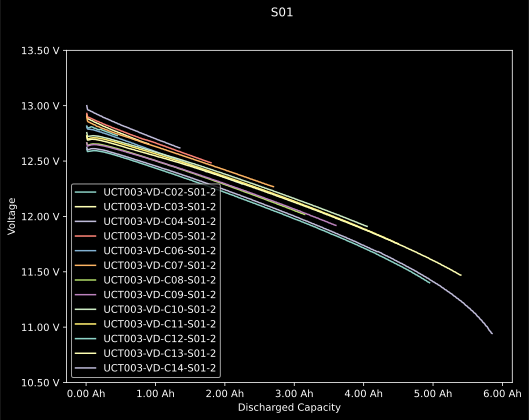

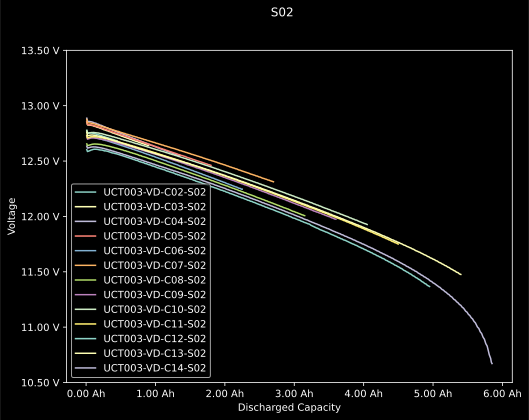

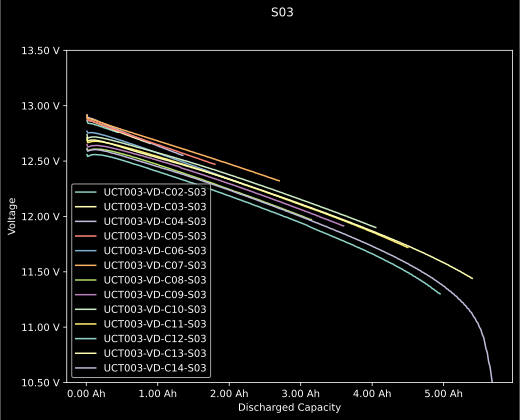

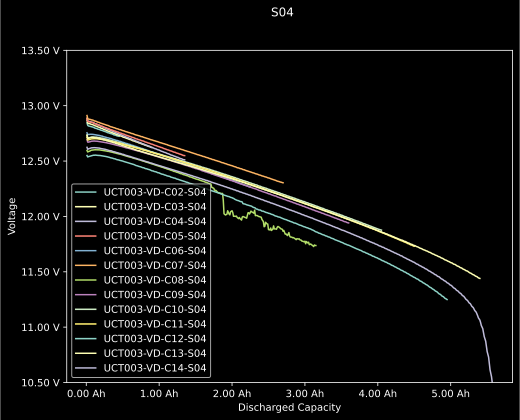

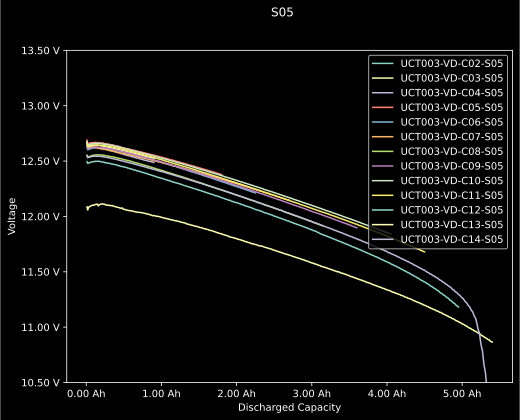

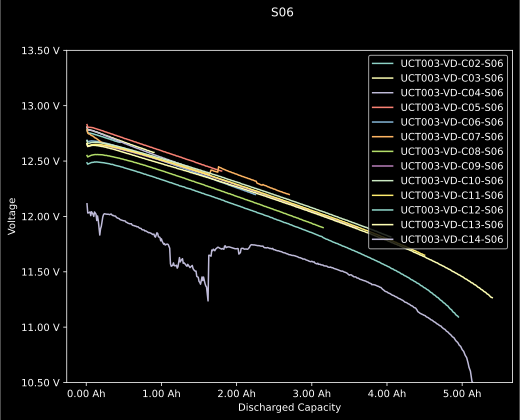

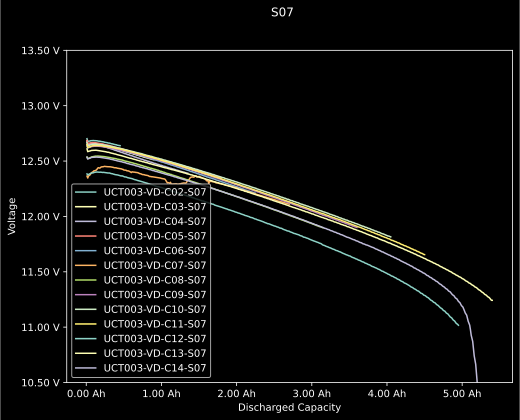

In [6]:
from itertools import groupby
from Lib.plot import volt_formatter, amp_hour_formatter


def plot_vd_stages(
    dfs: List[pd.DataFrame],
) -> List[plt.Figure]:
    df_stage = [
        list(group) for key, group in groupby(dfs, key=lambda x: x.attrs["stage"])
    ]

    figs = []

    for dfs_stage in df_stage:
        fig, ax = plt.subplots()

        for df in dfs_stage:
            ax.plot(-df["Amp-Hours"], df["Voltage"], label=df.attrs["test"])

        ax.set_xlabel("Discharged Capacity")
        ax.set_ylabel("Voltage")
        ax.legend()

        ax.xaxis.set_major_formatter(amp_hour_formatter)
        ax.yaxis.set_major_formatter(volt_formatter)

        ax.set_ylim(10.5, 13.5)

        fig.suptitle(dfs_stage[0].attrs["stage"])

        figs.append(fig)

    return figs


plot_vd_stages(vd_data)